# Data Processing 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv("credit_approval/credit_approval.csv")

In [3]:
# ── Preprocessing ────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

df_clean = df.dropna().reset_index(drop=True)
print(f"Rows after dropping missing: {len(df_clean)}  (dropped {len(df) - len(df_clean)})")

CAT_COLS  = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
CONT_COLS = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
FEATURES  = CAT_COLS + CONT_COLS
TARGET    = 'A16'

df_enc = df_clean.copy()
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder() # ordering
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

df_enc[TARGET] = (df_enc[TARGET] == '+').astype(int)

X            = df_enc[FEATURES].values.astype(float)
y            = df_enc[TARGET].values
feature_names = FEATURES

print(f"X shape: {X.shape}, class balance: {y.mean():.1%} approved (+)")

Rows after dropping missing: 653  (dropped 37)
X shape: (653, 15), class balance: 45.3% approved (+)


**Note:** 
1. We drop all rows that contain N.A., because 
    1. it only constitutes a very small fraction of dataset 
    2. imputation is risky when we don't know what each feature means 
2. LabelEncoder() might be problematic for multi-category featuers because it artificially introduces orders. Fortunately, in our case, none of these features contribute significantly (see later). 

# Model Training

In [4]:
# ── Model Selection via K-Fold CV ────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import warnings; warnings.filterwarnings('ignore')

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    return_train_score=False,
    n_jobs=-1,
    random_state=42,
    refit=False,
)
search.fit(X, y)

results   = pd.DataFrame(search.cv_results_)
AUC_FLOOR = 0.80
candidates  = results[results['mean_test_score'] > AUC_FLOOR]
best_idx    = candidates['std_test_score'].idxmin()
best_params = results.loc[best_idx, 'params']

print(f"Candidates above AUC >= {AUC_FLOOR}: {len(candidates)}")
print(f"Selected  mean AUC: {results.loc[best_idx, 'mean_test_score']:.4f}  "
      f"std: {results.loc[best_idx, 'std_test_score']:.4f}")
print(f"Params: {best_params}")

best_rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X, y)

Candidates above AUC >= 0.8: 60
Selected  mean AUC: 0.9366  std: 0.0282
Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}


RandomForestClassifier(max_depth=20, min_samples_leaf=4, min_samples_split=10,
                       n_jobs=-1, random_state=42)

**Note:**
1. We want to train a model that is (1) fairly accurate and (2) stable. 
2. The goal is not to **maximize** OOS prediction accuracy, but to identify which features drive decisions, in what direction, and how they interact. Interpretability is only meaningful when our model is stable. 
3. We use a RandomForest model and use randomized search to tune hyperparamters that yield most stable results across folds while maintaining a high AUC. 

# Feature Analysis and Interpretability

## SHAP and Feature Importance

In [5]:
# ── Per-Fold: Permutation Importance + SHAP Signs ────────────────────────
from sklearn.inspection import permutation_importance
import shap

fold_perm_imp   = []   # shape → (10, n_features)
fold_shap_signs = []   # mean SHAP per fold → (10, n_features)

for k, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    perm = permutation_importance(
        rf, X_val, y_val, scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1
    )
    fold_perm_imp.append(perm.importances_mean)

    expl = shap.TreeExplainer(rf)
    sv   = expl.shap_values(X_val)
    sv1  = sv[1] if isinstance(sv, list) else sv[..., 1] # safer code, depending on version
    fold_shap_signs.append(sv1.mean(axis=0))

    print(f"  fold {k+1:2d}/10", end='\r')

fold_perm_imp   = np.array(fold_perm_imp)    # (10, n_features)
fold_shap_signs = np.array(fold_shap_signs)  # (10, n_features)
print("Per-fold analysis complete.      ")

Per-fold analysis complete.      


In [6]:
# ── SHAP on Final Model (all data) ───────────────────────────────────────
explainer_final = shap.TreeExplainer(best_rf)
sv_final        = explainer_final.shap_values(X)
shap_approval   = sv_final[1] if isinstance(sv_final, list) else sv_final[..., 1]
# shap_approval: (n_samples, n_features)

mean_abs_shap = np.abs(shap_approval).mean(axis=0)
top_idx       = np.argsort(mean_abs_shap)[::-1]
top_features  = [feature_names[i] for i in top_idx]
TOP_N = 8

print("Feature ranking by mean |SHAP|:")
for rank, i in enumerate(top_idx):
    print(f"  {rank+1:2d}. {feature_names[i]:4s}  {mean_abs_shap[i]:.4f}")

Feature ranking by mean |SHAP|:
   1. A9    0.2034
   2. A11   0.0682
   3. A8    0.0559
   4. A15   0.0454
   5. A10   0.0419
   6. A14   0.0255
   7. A6    0.0220
   8. A3    0.0199
   9. A5    0.0116
  10. A2    0.0109
  11. A4    0.0104
  12. A7    0.0050
  13. A12   0.0029
  14. A1    0.0020
  15. A13   0.0019


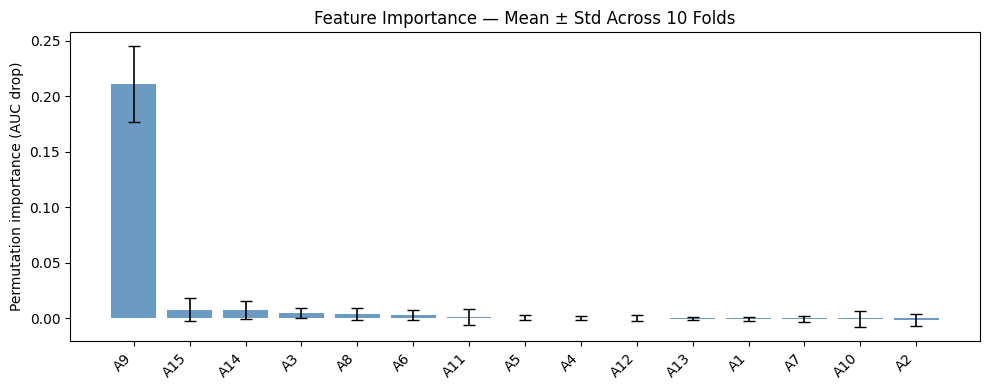

In [7]:
# ── Importance Stability: Mean ± Std Across 10 Folds ─────────────────────
mean_imp = fold_perm_imp.mean(axis=0)
std_imp  = fold_perm_imp.std(axis=0)
order    = np.argsort(mean_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(feature_names))
ax.bar(x, mean_imp[order], yerr=std_imp[order], capsize=4,
       color='steelblue', alpha=0.8, error_kw=dict(ecolor='black', lw=1.2))
ax.set_xticks(x)
ax.set_xticklabels([feature_names[i] for i in order], rotation=45, ha='right')
ax.set_ylabel("Permutation importance (AUC drop)")
ax.set_title("Feature Importance — Mean ± Std Across 10 Folds")
plt.tight_layout()
plt.show()

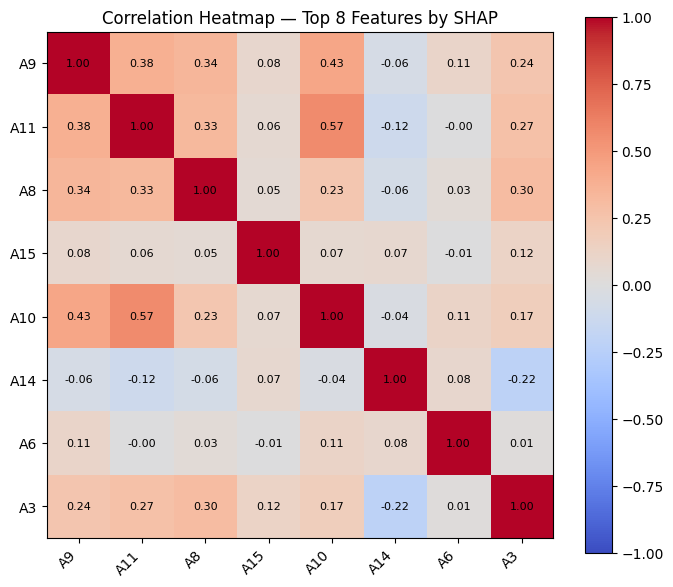

In [8]:
# ── Feature Correlations — Top Features ──────────────────────────────────
top8 = [feature_names[i] for i in top_idx[:TOP_N]]
corr = df_enc[top8].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(TOP_N)); ax.set_xticklabels(top8, rotation=45, ha='right')
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(top8)
for i in range(TOP_N):
    for j in range(TOP_N):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
ax.set_title(f"Correlation Heatmap — Top {TOP_N} Features by SHAP")
plt.tight_layout()
plt.show()

**Note** 
1. A9 has both SHAP and Feature Importance significantly higher than all other peers. It is the most important binary indicator that affects credit decision. 
2. A11, A8, and A10 are highly correlated with A9 and have moderately high SHAP yet low Feature Importance. It suggests that these three features are closely linked to A9 and make marginal contributions, although moderately to prediction accuracy. 
3. A15 and A14 are NOT correlated with A9 and have moderately high SHAP and high Feature Importance. Therefore, they are likely meaningful signals orthogonal to the A8-A11 group. 

## More in-depth Analyses 

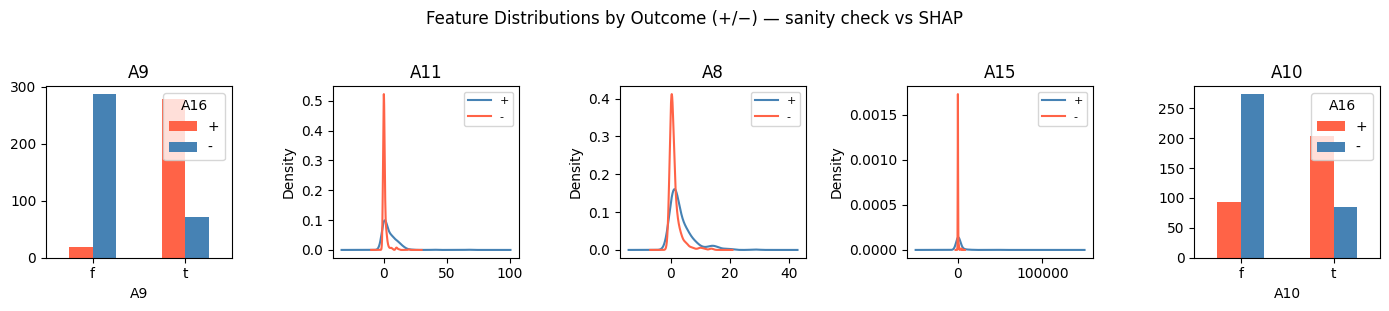

In [9]:
# ── Conditional Distributions by Outcome (model-free) ────────────────────
top5 = top_features[:5]
fig, axes = plt.subplots(1, len(top5), figsize=(14, 3))

for ax, feat in zip(axes, top5):
    pos = df_clean[df_clean['A16'] == '+'][feat]
    neg = df_clean[df_clean['A16'] == '-'][feat]

    if feat in CONT_COLS:
        pos.plot.kde(ax=ax, label='+', color='steelblue')
        neg.plot.kde(ax=ax, label='-', color='tomato')
        ax.legend(fontsize=8)
    else:
        grp = df_clean.groupby([feat, 'A16']).size().unstack(fill_value=0)
        grp.plot.bar(ax=ax, color=['tomato', 'steelblue'], legend=True)
        ax.tick_params(axis='x', rotation=0)
    ax.set_title(feat)

fig.suptitle("Feature Distributions by Outcome (+/−) — sanity check vs SHAP", y=1.02)
plt.tight_layout()
plt.show()

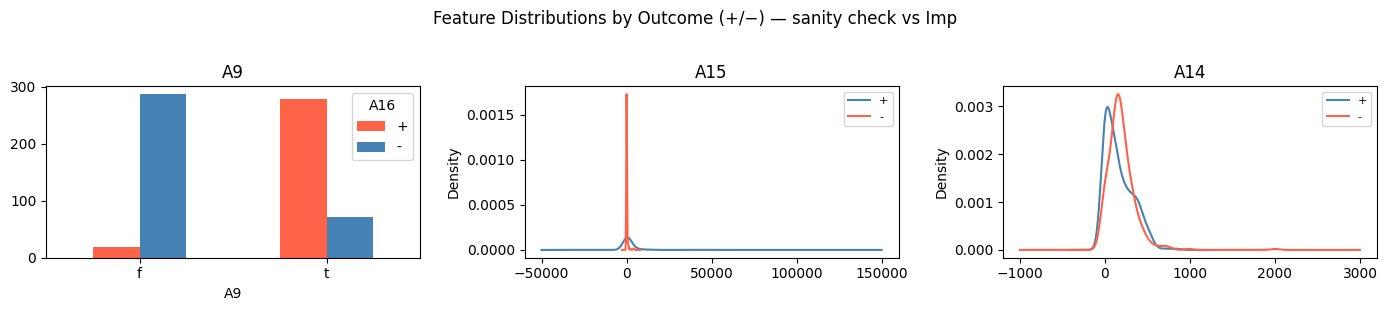

In [10]:
# ── Conditional Distributions by Outcome (model-free) ────────────────────
top5 = [feature_names[i] for i in order[:3]]
fig, axes = plt.subplots(1, len(top5), figsize=(14, 3))

for ax, feat in zip(axes, top5):
    pos = df_clean[df_clean['A16'] == '+'][feat]
    neg = df_clean[df_clean['A16'] == '-'][feat]

    if feat in CONT_COLS:
        pos.plot.kde(ax=ax, label='+', color='steelblue')
        neg.plot.kde(ax=ax, label='-', color='tomato')
        ax.legend(fontsize=8)
    else:
        grp = df_clean.groupby([feat, 'A16']).size().unstack(fill_value=0)
        grp.plot.bar(ax=ax, color=['tomato', 'steelblue'], legend=True)
        ax.tick_params(axis='x', rotation=0)
    ax.set_title(feat)

fig.suptitle("Feature Distributions by Outcome (+/−) — sanity check vs Imp", y=1.02)
plt.tight_layout()
plt.show()

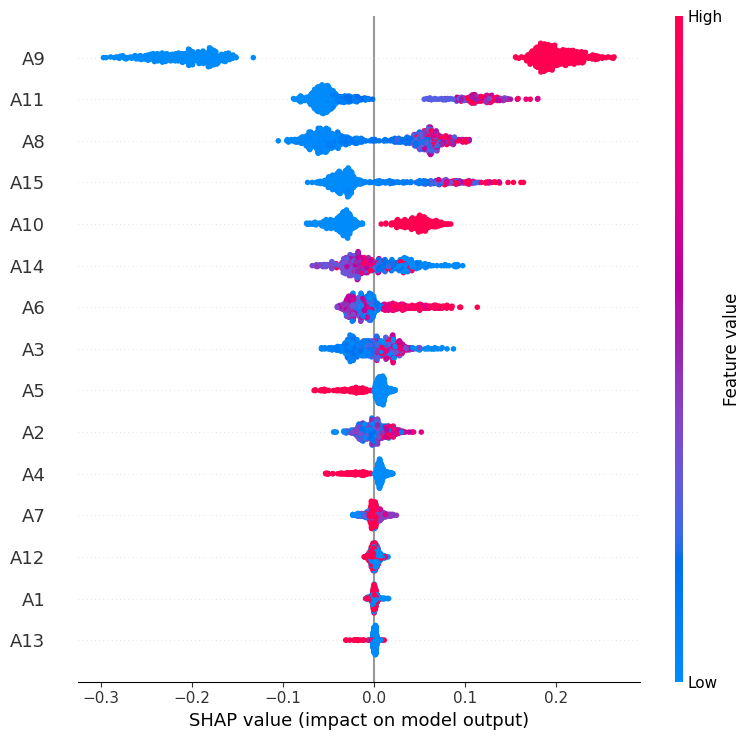

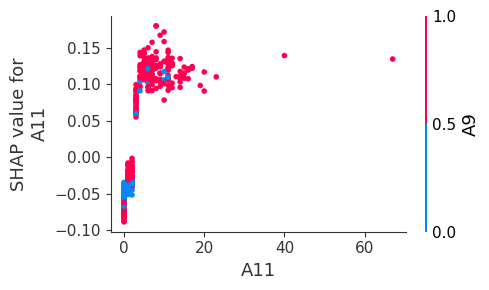

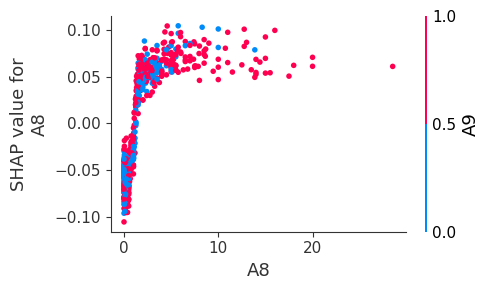

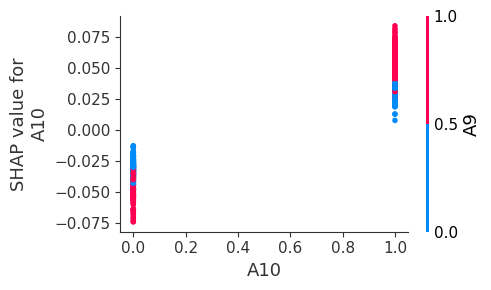

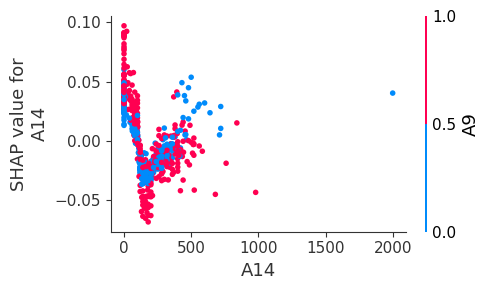

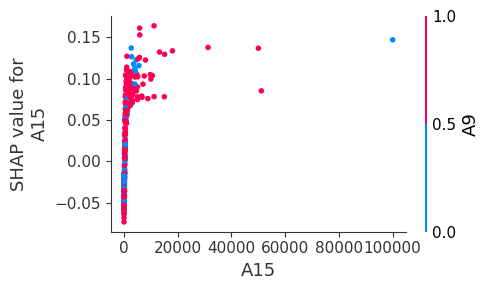

In [11]:
# ── SHAP Summary (beeswarm) + Dependence Plots ───────────────────────────
# Beeswarm importance ranking is valid for all features.
# Direction (color) is meaningful only for continuous and binary features;
# for multi-category nominals (A4, A5, A6, A7, A13) it reflects arbitrary
# label encoding — use the conditional bar charts above for those.
shap.summary_plot(shap_approval, X, feature_names=feature_names)

# Restrict dependence plots to features where the x-axis direction is interpretable
BINARY_CATS = ['A1', 'A9', 'A10', 'A12']
directional_feats = set(CONT_COLS + BINARY_CATS)
top_directional = [f for f in top_features if f in directional_feats]

for feat in ["A11", "A8", "A10", "A14", "A15"]:
    fig, ax = plt.subplots(figsize=(5, 3))
    shap.dependence_plot(feat, shap_approval, X,
                         feature_names=feature_names, ax=ax, show=False, interaction_index="A9")
    plt.tight_layout()
    plt.show()

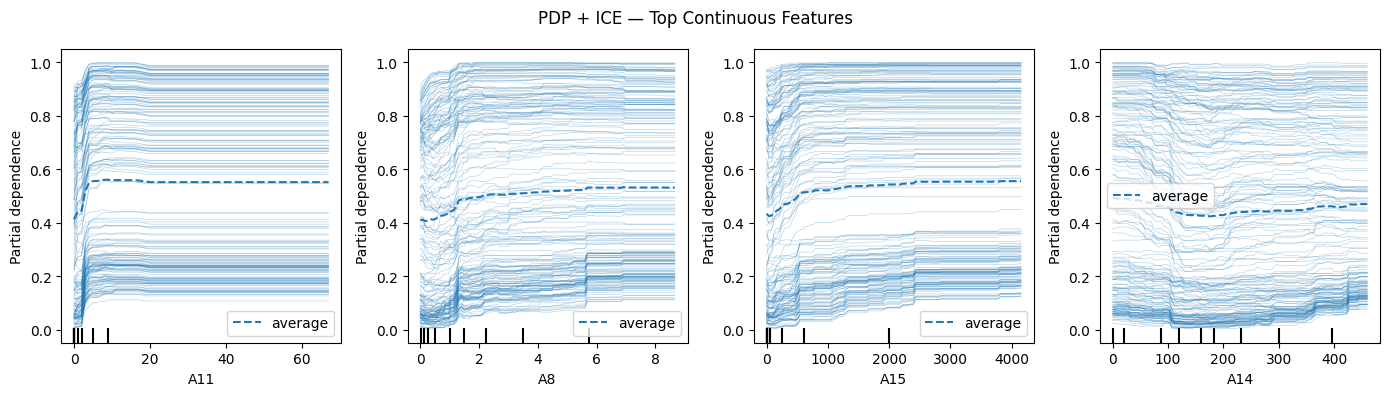

In [12]:
# ── PDP + ICE — Top Continuous Features ──────────────────────────────────
from sklearn.inspection import PartialDependenceDisplay

top_cont     = ["A11", "A8", "A15", "A14"]
top_cont_idx = [feature_names.index(f) for f in top_cont]

fig, axes = plt.subplots(1, len(top_cont_idx), figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X,
    features=top_cont_idx,
    kind='both',        # PDP (thick) + ICE (thin) lines
    subsample=200,
    feature_names=feature_names,
    ax=axes,
    random_state=42,
)
fig.suptitle("PDP + ICE — Top Continuous Features")
plt.tight_layout()
plt.show()

**Note (Conclusion)**
1. Analyses above furthur confirm that A9 is the cleanest, most important feature that predicts credit decision. 
2. A8, A10, A11 can be grouped with A9. They are highly correlated though noiser than A9. 
3. A15 is a signal indepedent from the A8-A11 group, and it only matters for a specific subgroup (extremely positive) rather than globally. This explains why its SHAP and Feature Importance are not as high as A9. 
4. A14 is noisier and likely capturing some nonlinear effects. 

## Final Stability Sanity Check

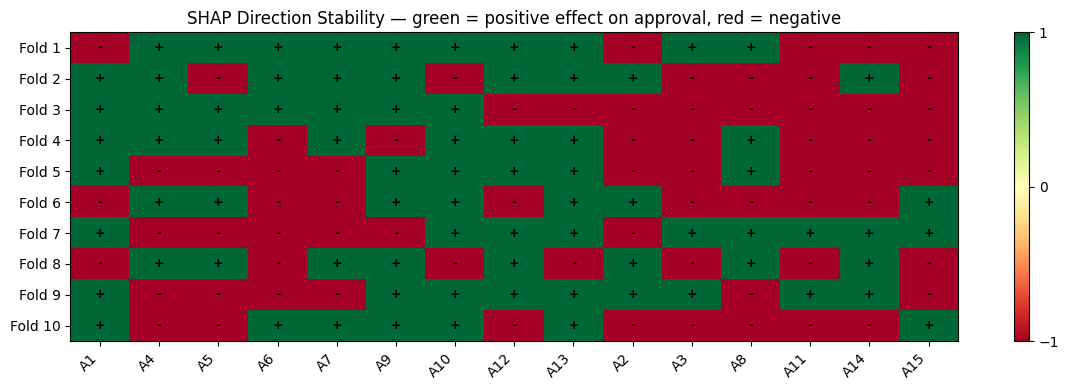

In [13]:
# ── SHAP Direction Stability Across 10 Folds ─────────────────────────────
sign_mat = np.sign(fold_shap_signs)  # (10, n_features)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(sign_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_yticks(range(10))
ax.set_yticklabels([f"Fold {i+1}" for i in range(10)])
for i in range(10):
    for j in range(len(feature_names)):
        ax.text(j, i, '+' if sign_mat[i, j] > 0 else '-',
                ha='center', va='center', fontsize=9, fontweight='bold')
ax.set_title("SHAP Direction Stability — green = positive effect on approval, red = negative")
plt.colorbar(im, ax=ax, ticks=[-1, 0, 1])
plt.tight_layout()
plt.show()

for j, feat in enumerate(feature_names):
    pos = int((sign_mat[:, j] > 0).sum())
    if pos not in (0, 10):
        print(f"WARNING: {feat} flips sign ({pos}/10 folds positive)")